<a href="https://colab.research.google.com/github/Reemabdi/League-of-Legends-Match-Predictor/blob/main/League_of_Legends_Match_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch


In [ ]:
# Import torch modules
import torch.nn as nn
import torch.optim as optim

# Define Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# Initialize the model
input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving league_of_legends_data_large (1).csv to league_of_legends_data_large (1).csv


In [ ]:
df = pd.read_csv('league_of_legends_data_large (1).csv')
df.head()


,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [ ]:
# Features and label
X = df.drop('win', axis=1)
y = df['win']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [ ]:
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)


X_train_tensor shape: torch.Size([800, 8])
y_train_tensor shape: torch.Size([800, 1])
X_test_tensor shape: torch.Size([200, 8])
y_test_tensor shape: torch.Size([200, 1])


In [ ]:
# Set number of epochs
epochs = 100

# Training loop
for epoch in range(epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [20/100], Loss: 0.7637
Epoch [40/100], Loss: 0.7565
Epoch [60/100], Loss: 0.7498
Epoch [80/100], Loss: 0.7438
Epoch [100/100], Loss: 0.7383


In [ ]:
# Evaluate accuracy
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor).round()
    test_preds = model(X_test_tensor).round()

    train_accuracy = (train_preds.eq(y_train_tensor).sum().item()) / len(y_train_tensor)
    test_accuracy = (test_preds.eq(y_test_tensor).sum().item()) / len(y_test_tensor)

print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Testing Accuracy: {test_accuracy:.4f}')


Training Accuracy: 0.4775
Testing Accuracy: 0.4900


In [ ]:
# Reinitialize model and optimizer with L2 regularization
model_l2 = LogisticRegressionModel(input_dim)
criterion_l2 = nn.BCELoss()
optimizer_l2 = optim.SGD(model_l2.parameters(), lr=0.01, weight_decay=0.01)  # L2 regularization

# Train the model with L2 regularization
for epoch in range(epochs):
    model_l2.train()
    outputs = model_l2(X_train_tensor)
    loss = criterion_l2(outputs, y_train_tensor)

    optimizer_l2.zero_grad()
    loss.backward()
    optimizer_l2.step()

    if (epoch+1) % 20 == 0:
        print(f"[L2] Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


[L2] Epoch [20/100], Loss: 0.7405
[L2] Epoch [40/100], Loss: 0.7356
[L2] Epoch [60/100], Loss: 0.7310
[L2] Epoch [80/100], Loss: 0.7268
[L2] Epoch [100/100], Loss: 0.7230


In [ ]:
# Evaluate L2-regularized model
model_l2.eval()
with torch.no_grad():
    train_preds_l2 = model_l2(X_train_tensor).round()
    test_preds_l2 = model_l2(X_test_tensor).round()

    train_acc_l2 = (train_preds_l2.eq(y_train_tensor).sum().item()) / len(y_train_tensor)
    test_acc_l2 = (test_preds_l2.eq(y_test_tensor).sum().item()) / len(y_test_tensor)

print(f"[L2] Training Accuracy: {train_acc_l2:.4f}")
print(f"[L2] Testing Accuracy: {test_acc_l2:.4f}")


[L2] Training Accuracy: 0.5150
[L2] Testing Accuracy: 0.4450


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import numpy as np


In [ ]:
# Get predictions as probabilities and class labels
probs = model_l2(X_test_tensor).detach().numpy()
preds = (probs >= 0.5).astype(int)
y_true = y_test_tensor.numpy()


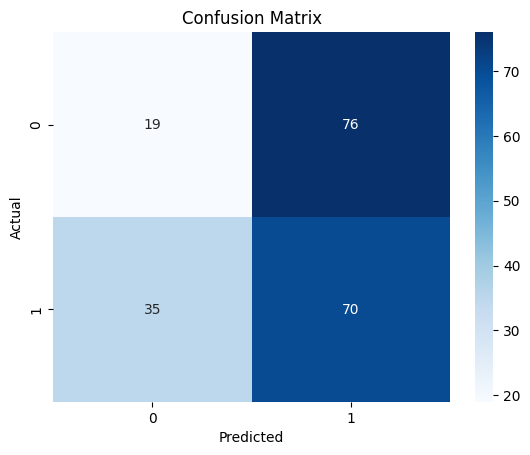

Classification Report:

              precision    recall  f1-score   support

         0.0       0.35      0.20      0.26        95
         1.0       0.48      0.67      0.56       105

    accuracy                           0.45       200
   macro avg       0.42      0.43      0.41       200
weighted avg       0.42      0.45      0.41       200



In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, preds))


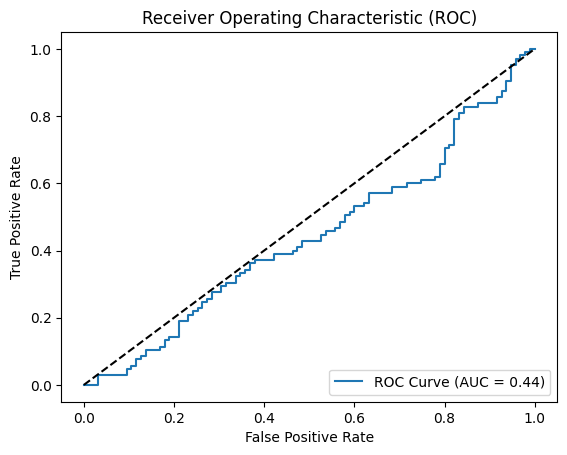

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Receiver Operating Characteristic (ROC)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Save the L2-trained model
torch.save(model_l2.state_dict(), "logistic_model_l2.pth")
print("Model saved successfully.")


Model saved successfully.


In [ ]:
# Recreate model structure
loaded_model = LogisticRegressionModel(input_dim)

# Load saved weights
loaded_model.load_state_dict(torch.load("logistic_model_l2.pth"))

# Set to evaluation mode
loaded_model.eval()


LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
with torch.no_grad():
    loaded_preds = loaded_model(X_test_tensor).round()
    loaded_acc = (loaded_preds.eq(y_test_tensor).sum().item()) / len(y_test_tensor)

print(f"Accuracy of loaded model: {loaded_acc:.4f}")


Accuracy of loaded model: 0.4450


In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
results = {}


In [ ]:
for lr in learning_rates:
    model_tuned = LogisticRegressionModel(input_dim)
    optimizer_tuned = optim.SGD(model_tuned.parameters(), lr=lr, weight_decay=0.01)
    criterion_tuned = nn.BCELoss()

    for epoch in range(50):  # fewer epochs to speed up
        model_tuned.train()
        outputs = model_tuned(X_train_tensor)
        loss = criterion_tuned(outputs, y_train_tensor)

        optimizer_tuned.zero_grad()
        loss.backward()
        optimizer_tuned.step()

    # Evaluate
    model_tuned.eval()
    with torch.no_grad():
        preds = model_tuned(X_test_tensor).round()
        acc = (preds.eq(y_test_tensor).sum().item()) / len(y_test_tensor)

    results[lr] = acc
    print(f"Learning Rate: {lr} → Test Accuracy: {acc:.4f}")


Learning Rate: 0.001 → Test Accuracy: 0.5050
Learning Rate: 0.01 → Test Accuracy: 0.5000
Learning Rate: 0.1 → Test Accuracy: 0.4450
Learning Rate: 0.5 → Test Accuracy: 0.5100


In [ ]:
best_lr = max(results, key=results.get)
print(f"\n✅ Best Learning Rate: {best_lr} with Accuracy: {results[best_lr]:.4f}")



✅ Best Learning Rate: 0.5 with Accuracy: 0.5100


In [ ]:
# Extract weights from the linear layer
weights = model_l2.linear.weight.detach().numpy().flatten()


In [ ]:
# Match with original feature names
feature_names = X.columns.tolist()

import pandas as pd
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': weights
})

# Sort by absolute importance
importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

importance_df = importance_df.drop(columns='Abs_Importance')  # drop temp column
importance_df


,Feature,Importance
3,gold_earned,0.272118
7,damage_dealt,0.247066
6,wards_killed,-0.195455
1,deaths,0.190506
2,assists,0.170044
5,wards_placed,-0.141483
0,kills,0.136153
4,cs,-0.042634


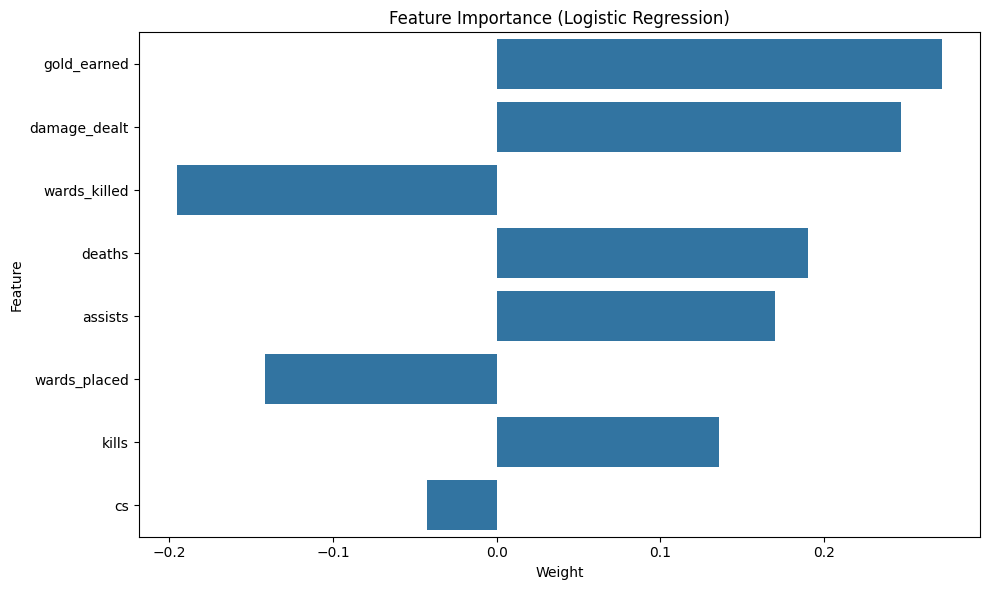

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
